In [1]:
!pip install shap xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import shap
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

print("Готово")

Готово


In [5]:
target_col = 'Target'
df = pd.read_csv('dataset.csv')
print("Размер датасета:", df.shape)
print("\nПервые 5 строк:")
df.head()

Размер датасета: (4424, 35)

Первые 5 строк:


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [6]:
print("Типы данных:")
print(df.dtypes)
print("\nПропущенные значения:")
print(df.isnull().sum())
print("\nУникальные значения целевой переменной:")
print(df['Target'].value_counts())

Типы данных:
Marital status                                      int64
Application mode                                    int64
Application order                                   int64
Course                                              int64
Daytime/evening attendance                          int64
Previous qualification                              int64
Nacionality                                         int64
Mother's qualification                              int64
Father's qualification                              int64
Mother's occupation                                 int64
Father's occupation                                 int64
Displaced                                           int64
Educational special needs                           int64
Debtor                                              int64
Tuition fees up to date                             int64
Gender                                              int64
Scholarship holder                                  int64
A

In [7]:
# Выбираем несколько числовых признаков для анализа
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numeric_cols:
    numeric_cols.remove(target_col)

print(f"Числовых признаков: {len(numeric_cols)}")
print("Примеры:", numeric_cols[:10])

Числовых признаков: 34
Примеры: ['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation"]


In [11]:
# Кодируем категориальные признаки (если есть)
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

# Разделяем на признаки (X) и целевую переменную (y)
X = df.drop(columns=[target_col])
y = df[target_col]

# Преобразуем в бинарную: Dropout (0) vs остальные (1)
# Если 0 = Dropout, а 1 и 2 = не Dropout
y = (y != 0).astype(int)
print("0 = Dropout, 1 = Не Dropout (Graduate + Enrolled)")
print("Распределение:")
print(y.value_counts())

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Масштабирование
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")
print("Предобработка завершена!")

0 = Dropout, 1 = Не Dropout (Graduate + Enrolled)
Распределение:
Target
1    3003
0    1421
Name: count, dtype: int64

Train: (3539, 34), Test: (885, 34)
Предобработка завершена!


In [13]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    results.append({
        'Модель': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })

df_results = pd.DataFrame(results).round(4)
print("Результаты моделей:")
df_results

Результаты моделей:


,Модель,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.8734,0.8791,0.9434,0.9101,0.9173
1,Random Forest,0.8768,0.8808,0.9468,0.9126,0.9213
2,XGBoost,0.8678,0.8793,0.9334,0.9056,0.9141


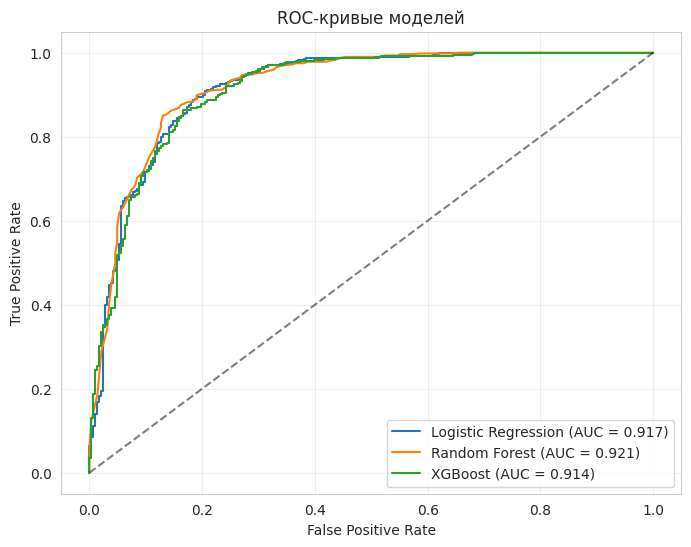

In [14]:
plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые моделей')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

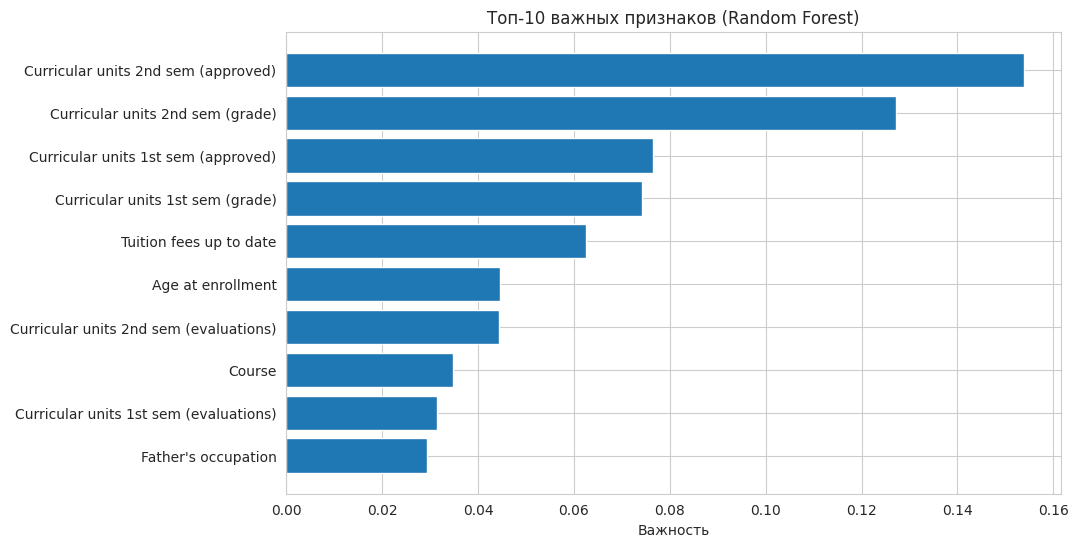

Топ-10 важных признаков:
                                   feature  importance
28     Curricular units 2nd sem (approved)    0.153937
29        Curricular units 2nd sem (grade)    0.127243
22     Curricular units 1st sem (approved)    0.076577
23        Curricular units 1st sem (grade)    0.074194
14                 Tuition fees up to date    0.062584
17                       Age at enrollment    0.044566
27  Curricular units 2nd sem (evaluations)    0.044363
3                                   Course    0.034693
21  Curricular units 1st sem (evaluations)    0.031386
10                     Father's occupation    0.029341


In [19]:
# Важность признаков — Random Forest
importances = models['Random Forest'].feature_importances_
feature_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values('importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(feature_imp['feature'], feature_imp['importance'])
plt.xlabel('Важность')
plt.title('Топ-10 важных признаков (Random Forest)')
plt.gca().invert_yaxis()
plt.show()

print("Топ-10 важных признаков:")
print(feature_imp)

In [20]:
import pickle

# Сохраняем лучшую модель (Random Forest) и scaler
with open('best_model.pkl', 'wb') as f:
    pickle.dump(models['Random Forest'], f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Сохраняем названия признаков
with open('feature_names.pkl', 'wb') as f:
    pickle.dump(X.columns.tolist(), f)

print("Файлы сохранены: best_model.pkl, scaler.pkl, feature_names.pkl")

Файлы сохранены: best_model.pkl, scaler.pkl, feature_names.pkl
